In [1]:
import pickle
from collections import Counter

import graphviz
import matplotlib.pyplot as plt
import pandas as pd

from utils.experiment import load_config
from utils.streaming.factories import create_transformer
from utils.streaming.inference import infer_trace

In [2]:
results_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/BPIC_20_DD/aht_index_bpic20dd_2026-02-28_13-07-58.csv'

model_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/BPIC_20_DD/aht_index_bpic20dd_2026-02-28_13-07-58.pkl'

config_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/conf/experiments/streaming/aht/BPIC_20_DD.yaml'

dataset_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/BPIC_20_DD.xes'

### Load Results and Model

In [3]:
# load config
config = load_config(config_path)

# load model
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# load results from csv
results_df = pd.read_csv(results_path)

print(f'Results rows: {len(results_df)}')
print(f'Model type: {type(model).__name__}')
print('Model params:')
for k, v in model._get_params().items():
    print(f'  {k:<30}: {v}')

Results rows: 45937
Model type: HoeffdingAdaptiveTreeClassifier
Model params:
  grace_period                  : 100
  max_depth                     : 20
  split_criterion               : info_gain
  delta                         : 0.001
  tau                           : 0.05
  leaf_prediction               : nba
  nb_threshold                  : 10
  nominal_attributes            : None
  splitter                      : (<class 'river.tree.splitter.gaussian_splitter.GaussianSplitter'>, {'n_splits': 10})
  bootstrap_sampling            : True
  drift_window_threshold        : 300
  drift_detector                : (<class 'river.drift.adwin.ADWIN'>, {'delta': 0.002, 'clock': 32, 'max_buckets': 5, 'min_window_length': 5, 'grace_period': 10})
  switch_significance           : 0.05
  binary_split                  : False
  min_branch_fraction           : 0.01
  max_share_to_split            : 0.99
  max_size                      : 100.0
  memory_estimate_period        : 1000000
  stop_mem_m

## Adaptive Hoeffding Tree (AHT)

### Tree Structure

#### Helper functions

In [68]:
def build_dot(node, dot=None, parent_id=None, edge_label='', node_counter=None):
    if dot is None:
        dot = graphviz.Digraph(graph_attr={'rankdir': 'TB'})
        node_counter = [0]

    if node is None:
        return dot

    node_id = str(node_counter[0])
    node_counter[0] += 1

    feature = getattr(node, 'feature', None)
    children_raw = getattr(node, 'children', {})

    # normalise to dict {label: child_node}
    if isinstance(children_raw, dict):
        children = children_raw
    elif isinstance(children_raw, list):
        children = {str(i): child for i, child in enumerate(children_raw)}
    else:
        children = {}

    if feature is not None:
        # Branch node
        label = f'split: {feature}'
        dot.node(node_id, label=label, shape='box', style='filled', fillcolor='#AED6F1')
    else:
        # Leaf node — 'stats' is the correct attribute (not '_stats')
        stats = getattr(node, 'stats', {})
        if stats:
            total = sum(stats.values())
            sorted_classes = sorted(stats.items(), key=lambda x: x[1], reverse=True)
            lines = [f'total: {total:.0f}'] + [
                f'{cls}: {cnt:.0f}' for cls, cnt in sorted_classes[:5]
            ]
            if len(sorted_classes) > 5:
                lines.append(f'... +{len(sorted_classes) - 5} more')
            label = '\n'.join(lines)
        else:
            label = 'leaf\n(empty)'
        dot.node(
            node_id, label=label, shape='ellipse', style='filled', fillcolor='#A9DFBF'
        )

    if parent_id is not None:
        dot.edge(parent_id, node_id, label=str(edge_label))

    for child_key, child in children.items():
        build_dot(
            child,
            dot,
            parent_id=node_id,
            edge_label=child_key,
            node_counter=node_counter,
        )

    return dot


def collect_split_features(node, counter=None):
    if counter is None:
        counter = Counter()
    if node is None:
        return counter

    feature = getattr(node, 'feature', None)
    if feature is not None:
        counter[feature] += 1

    children_raw = getattr(node, 'children', {})
    if isinstance(children_raw, dict):
        children = list(children_raw.values())
    elif isinstance(children_raw, list):
        children = children_raw
    else:
        children = []

    for child in children:
        collect_split_features(child, counter)

    return counter

#### Analysis

In [44]:
summary = model.summary
print('Tree structure summary:')
for k, v in summary.items():
    print(f'{k:<25}: {v}')

print(f'\nMemory usage: {model._raw_memory_usage:,} bytes')

Tree structure summary:
n_nodes                  : 12
n_branches               : 2
n_leaves                 : 10
n_active_leaves          : 130
n_inactive_leaves        : 0
height                   : 3
total_observed_weight    : 45937.0
n_alternate_trees        : 8
n_pruned_alternate_trees : 0
n_switch_alternate_trees : 0

Memory usage: 10,643,832 bytes


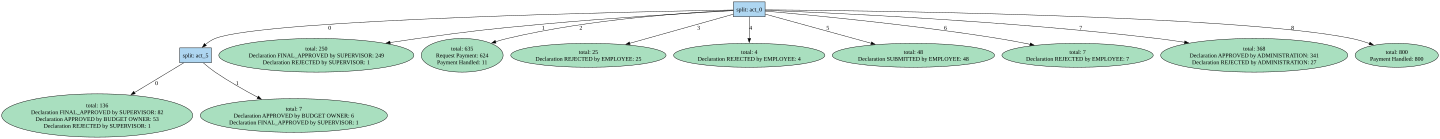

In [52]:
dot = build_dot(model._root)
dot.attr(size='20,20')
display(dot)

Distinct features used in splits: 2


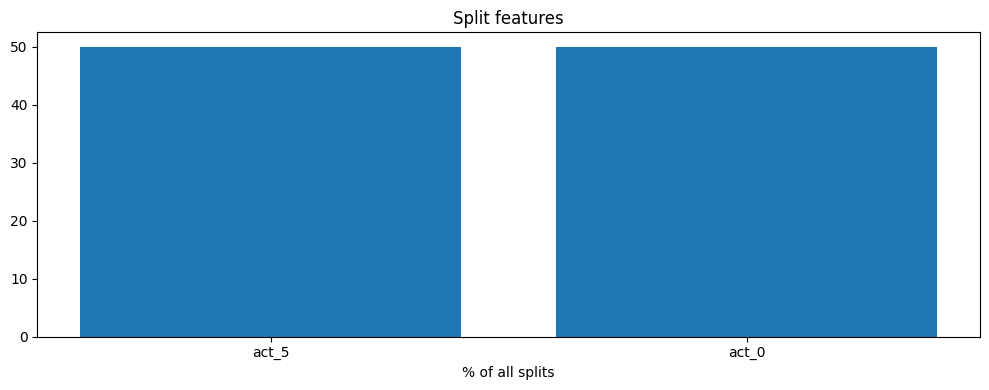

In [71]:
split_counts = collect_split_features(model._root)
fi_df = (
    pd.DataFrame(split_counts.items(), columns=['feature', 'split_count'])
    .sort_values('split_count', ascending=False)
    .reset_index(drop=True)
)
fi_df['split_pct'] = fi_df['split_count'] / fi_df['split_count'].sum() * 100

print(f'Distinct features used in splits: {len(fi_df)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fi_df['feature'][::-1], fi_df['split_pct'][::-1])
ax.set_xlabel('% of all splits')
ax.set_title('Split features')
plt.tight_layout()
plt.show()

In [70]:
drift_det = getattr(model, 'drift_detector', None)

print(f'Number of drifts detected: {getattr(drift_det, "n_detections", "n/a")}')

Number of drifts detected: 0


#### Test predictions

In [7]:
trace_id = None
seed = 123

transformer = create_transformer(config['transformer'])

trace_df, trace_id = infer_trace(
    model=model,
    transformer=transformer,
    dataset_path=dataset_path,
    trace_id=trace_id,
    seed=seed,
)

print(f'Trace ID: {trace_id}')
print(f'Length: {len(trace_df)} events')
print(f'Accuracy: {trace_df["correct"].dropna().mean():.2%}\n')

display(trace_df)

Trace ID: declaration 88175
Length: 4 events
Accuracy: 66.67%



,step,prefix_len,y_true,y_pred,y_pred_prob,correct
0,0,0,Declaration SUBMITTED by EMPLOYEE,None,NaN,None
1,1,1,Declaration FINAL_APPROVED by SUPERVISOR,Declaration APPROVED by ADMINISTRATION,0.926630,False
2,2,2,Request Payment,Request Payment,0.995006,True
3,3,3,Payment Handled,Payment Handled,1.000000,True


## Training curves